# Лабораторна робота 5
## 2 Варіант

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### $$f(x) = x^2 \cos x, \quad x \in \left[-\frac{\pi}{2}, \pi \right]$$

In [110]:
def func(x):
    return x**2 * np.cos(x)

a, b = -np.pi/2, np.pi

## Визначення функції та вузлів

In [111]:
n_nodes = 15  

x_nodes = np.linspace(a, b, n_nodes)
y_nodes = np.round(func(x_nodes), 4)

table = pd.DataFrame({'x': np.round(x_nodes,4), 'f(x)': y_nodes})

print(table)

         x    f(x)
0  -1.5708  0.0000
1  -1.2342  0.5031
2  -0.8976  0.5023
3  -0.5610  0.2665
4  -0.2244  0.0491
5   0.1122  0.0125
6   0.4488  0.1815
7   0.7854  0.4362
8   1.1220  0.5462
9   1.4586  0.2382
10  1.7952 -0.7171
11  2.1318 -2.4178
12  2.4684 -4.7637
13  2.8050 -7.4265
14  3.1416 -9.8696


## Поліном Лагранжа

In [112]:
def lagrange_poly(x, x_nodes, y_nodes):
    
    n = len(x_nodes)
    L = np.zeros_like(x, dtype=float)
    for i in range(n):
        term = y_nodes[i] * np.ones_like(x)
        for j in range(n):
            if i != j:
                term *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        L += term
        
    return L

## Кубічний сплайн

In [113]:
def cubic_spline(x, x_nodes, y_nodes):

    n = len(x_nodes) - 1
    h = np.diff(x_nodes)

    alpha = np.zeros(n-1)
    for i in range(1, n):
        alpha[i-1] = (3/h[i])*(y_nodes[i+1]-y_nodes[i]) - (3/h[i-1])*(y_nodes[i]-y_nodes[i-1])

    l = np.ones(n+1)
    mu = np.zeros(n)
    z = np.zeros(n+1)
    c = np.zeros(n+1)
    b = np.zeros(n)
    d = np.zeros(n)
    a = y_nodes[:-1]

    for i in range(1, n):
        l[i] = 2*(x_nodes[i+1]-x_nodes[i-1]) - h[i-1]*mu[i-1]
        mu[i] = h[i]/l[i]
        z[i] = (alpha[i-1] - h[i-1]*z[i-1])/l[i]

    for j in range(n-1, -1, -1):
        c[j] = z[j] - mu[j]*c[j+1]
        b[j] = (y_nodes[j+1]-y_nodes[j])/h[j] - h[j]*(c[j+1]+2*c[j])/3
        d[j] = (c[j+1]-c[j])/(3*h[j])

    x = np.array(x)
    y = np.zeros_like(x, dtype=float)

    for i in range(n):
        mask = (x >= x_nodes[i]) & (x <= x_nodes[i+1])
        dx = x[mask] - x_nodes[i]
        y[mask] = a[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3

    return y

## Побудова графіків 

In [ ]:
h_node = x_nodes[1] - x_nodes[0]

x = np.linspace( x_nodes[0], x_nodes[-1], int((x_nodes[-1] - x_nodes[0]) / (h_node / 5)))

y_exact = func(x)
y_lagrange = lagrange_poly(x, x_nodes, y_nodes)
y_spline = cubic_spline(x, x_nodes, y_nodes)

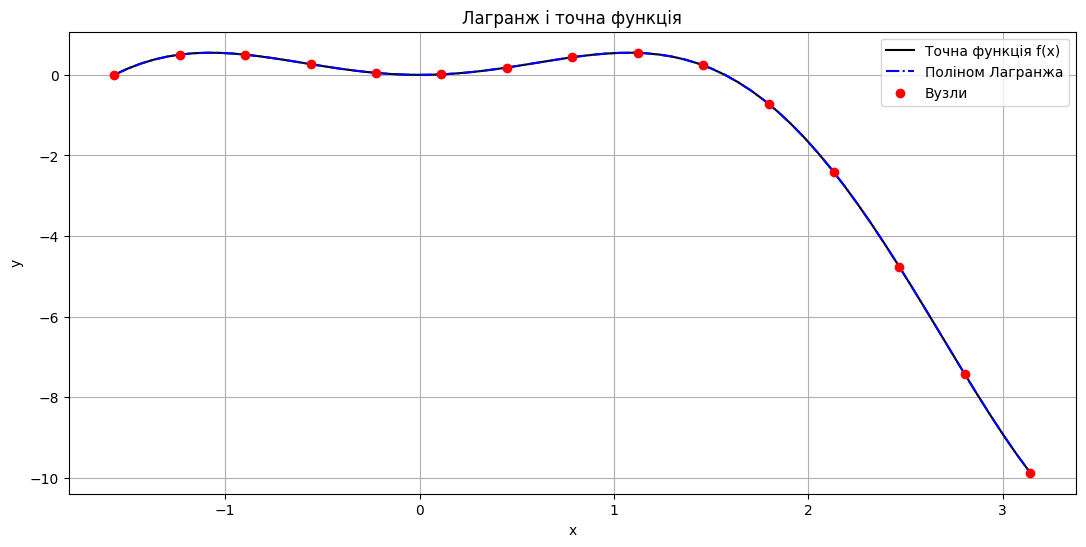

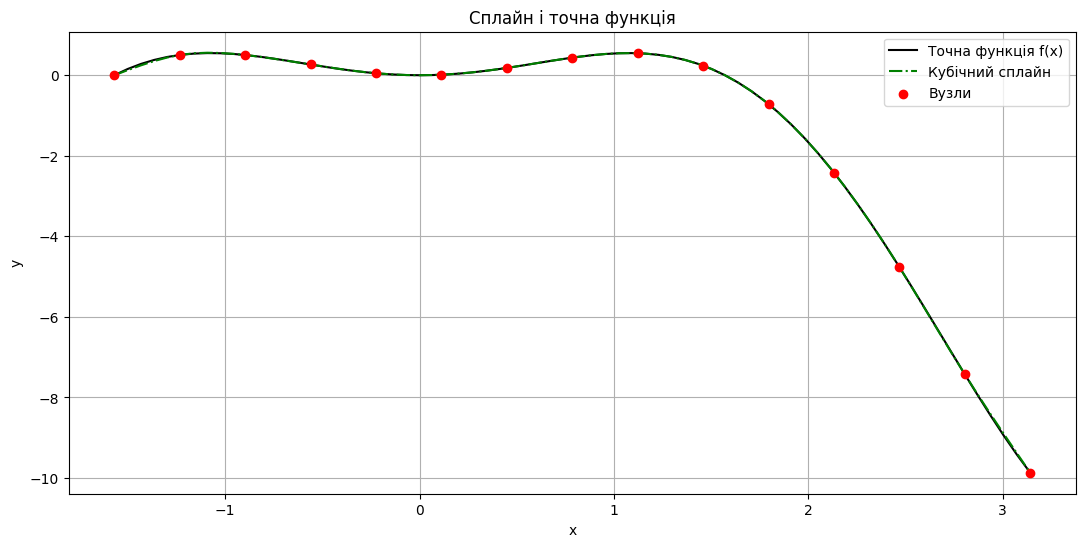

In [115]:
plots = [
    {
        "y": y_lagrange,
        "style": 'b-.',
        "label": 'Поліном Лагранжа',
        "title": 'Лагранж і точна функція'
    },
    {
        "y": y_spline,
        "style": 'g-.',
        "label": 'Кубічний сплайн',
        "title": 'Сплайн і точна функція'
    }
]

for plot_data in plots:
    
    plt.figure(figsize=(13, 6))
    plt.plot(x, y_exact, 'k', label='Точна функція f(x)')
    plt.plot(x, plot_data["y"], plot_data["style"], label=plot_data["label"])
    plt.scatter(x_nodes, y_nodes, color='red', zorder=5, label='Вузли')
    plt.title(plot_data["title"])
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

## Похибка інтерполяції

In [116]:
e_lagrange = np.abs(y_lagrange - y_exact)
e_spline = np.abs(y_spline- y_exact)

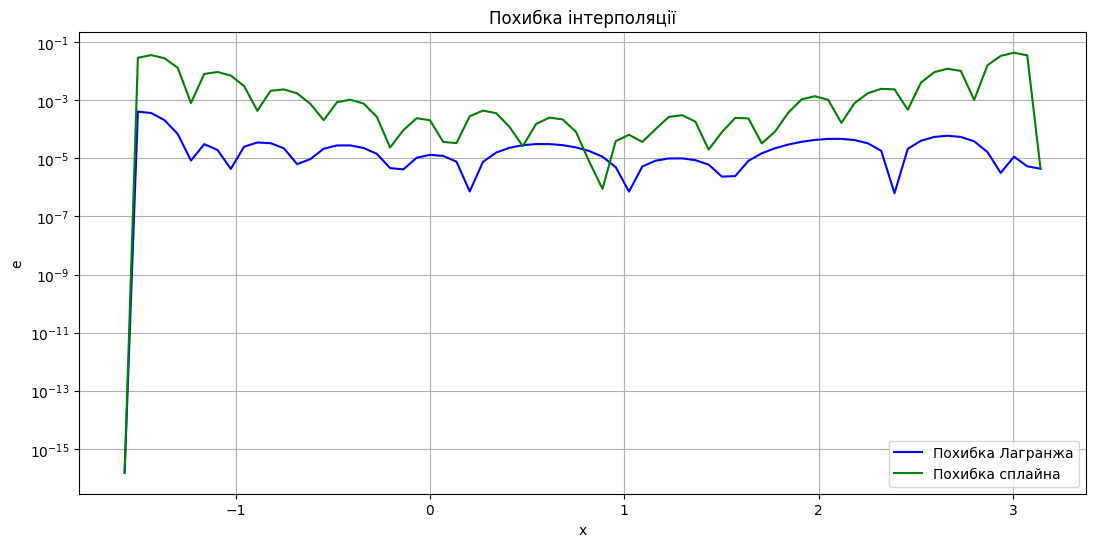

In [117]:
plt.figure(figsize=(13, 6))
plt.plot(x, e_lagrange, 'b', label='Похибка Лагранжа')
plt.plot(x, e_spline, 'g', label='Похибка сплайна')
plt.title('Похибка інтерполяції')
plt.xlabel('x')
plt.ylabel('e')
plt.legend()
plt.grid(True)
plt.yscale('log')

In [118]:
max_e_lagrange = np.max(e_lagrange)
max_e_spline = np.max(e_spline)

print("Максимальна похибка (Лагранж):", max_e_lagrange)
print("Максимальна похибка (Сплайн):", max_e_spline)

Максимальна похибка (Лагранж): 0.00040359888385896325
Максимальна похибка (Сплайн): 0.04322520636387317
